# Лабораторная работа 3. Оптимизация, регуляризация и робастность нейросети

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Экспериментально проверить, как выбор оптимизатора и методов регуляризации влияет на сходимость, переобучение, обобщение и чувствительность модели к возмущениям входа.

## Результаты обучения
После выполнения работы вы должны уметь:
- объяснять идею прямого прохода и backpropagation через цепное правило;
- различать SGD, Momentum и Adam с точки зрения траектории оптимизации и свойств найденного минимума;
- применять L2-регуляризацию, Dropout, BatchNorm и early stopping;
- оценивать train/test gap как признак переобучения;
- связывать переобучение и уязвимость модели к малым возмущениям входа.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

RANDOM_STATE = 18
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1. Данные

**Задание:** загрузите датасет для классификации изображений.
Рекомендуется MNIST или Fashion-MNIST (через `torchvision.datasets`). 


In [4]:
# Определяем среднее и отклонение для нормализации
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

images = torch.cat([
    image for image, _ in train_dataset
])

mean = images.mean()
std = images.std()

print(mean)
print(std)

tensor(0.1307)
tensor(0.3081)


In [5]:
# Преобразуем и нормализуем изображения
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Загружаем датасет (обучающая и тестовая выборки) и применяем Трансформ
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Создание DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True, # Перемешивание
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print(f"Размер train_dataset: {len(train_dataset)} изображений")
print(f"Размер test_dataset: {len(test_dataset)} изображений")
print(f"Количество батчей в train_loader: {len(train_loader)}")
print(f"Количество батчей в test_loader: {len(test_loader)}")


Размер train_dataset: 60000 изображений
Размер test_dataset: 10000 изображений
Количество батчей в train_loader: 938
Количество батчей в test_loader: 157


## 2. Формализм прямого прохода и backpropagation

**Задание:** опишите (в markdown, формулами) прямой проход для вашей архитектуры и кратко распишите, как вычисляется ошибка слоя \( \delta^{(l)} \) через цепное правило.

**Вопрос для отчёта:** почему backpropagation имеет вычислительную сложность \(O(P)\) по числу параметров, а не \(O(2P)\), как при наивном численном дифференцировании?


_Ваш ответ (формулы и объяснение):_

Для входного изображения сеть последовательно вычисляет:

$$
z^{(1)}=W^{(1)}x+b^{(1)},
$$

$$
a^{(1)}=ReLU(z^{(1)}),
$$

$$
z^{(2)}=W^{(2)}a^{(1)}+b^{(2)}.
$$

На выходе получаем 10 чисел (логиты). При использовании Softmax они могут быть преобразованы в вероятности классов.

При backpropagation ошибка распространяется от выхода сети к входу по цепному правилу. Для последнего слоя при использовании Softmax и Cross-Entropy:

$$
\delta^{(2)}=p-y,
$$

где \(p\) — предсказание модели, а \(y\) — правильная метка. Затем ошибка передаётся на предыдущие слои, например:

$$
\delta^{(1)}
=
(W^{(2)})^T\delta^{(2)}
\odot ReLU'(z^{(1)}).
$$


Backpropagation получает градиенты всех параметров за один обратный проход, используя результаты прямого прохода. При численном дифференцировании приходится отдельно вычислять функцию для каждого параметра. Поэтому backpropagation значительно эффективнее.


## 3. Базовая архитектура сети

In [6]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super().__init__()
        
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm
        
        # Первый слой
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        
        # BatchNorm после первого слоя
        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(hidden_dim)
        
        # Dropout
        if use_dropout:
            self.dropout = nn.Dropout(dropout_p)
        
        # Второй слой
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        
        if use_batchnorm:
            self.bn2 = nn.BatchNorm1d(hidden_dim)
        
        # Третий слой
        self.fc3 = nn.Linear(hidden_dim, num_classes)
        
        # Функция активации
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Первый слой
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu(x)
        if self.use_dropout:
            x = self.dropout(x)
        
        # Второй слой
        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu(x)
        if self.use_dropout:
            x = self.dropout(x)
        
        # Третий слой (выходной)
        x = self.fc3(x)
        
        return x

In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(loader):
        # Перенос на устройство (CPU/GPU)
        data, target = data.to(device), target.to(device)
        
        # Преобразуем в вектор (1*28*28)
        if data.dim() > 2:
            data = data.view(data.size(0), -1)
        
        # Обнуление градиентов после каждого батча
        optimizer.zero_grad()
        
        output = model(data)
        
        loss = criterion(output, target)
        
        # Обратный проход и оптимизация (обновление весов)
        loss.backward()
        optimizer.step()
        
        # Статистика
        total_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    # Средние значения
    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy

# Для тестовой выборки
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  # Не вычисляем градиенты
        for data, target in loader:
            # Перенос на устройство
            data, target = data.to(device), target.to(device)
            
            if data.dim() > 2:
                data = data.view(data.size(0), -1)
            
            output = model(data)
            
            loss = criterion(output, target)
            
            # Статистика
            total_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    # Средние значения
    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy


## 4. Серия A. Сравнение оптимизаторов

**Задание:** обучите одну и ту же архитектуру (без дополнительной регуляризации) со следующими оптимизаторами:
- SGD;
- SGD + Momentum (momentum=0.9);
- Adam.

Для каждого варианта зафиксируйте одинаковое число эпох и одинаковый learning rate (или обоснуйте отличие).


In [8]:
# Обучение модели
def train_model(model, train_loader, test_loader, optimizer, criterion, device, epochs=10):
    history = {
        "train_loss": [], 
        "test_loss": [], 
        "train_acc": [], 
        "test_acc": []
    }
    
    for epoch in range(epochs):
        # Обучение
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        
        # Оценка
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        # Сохранение истории
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    
    return history

# Инициализация модели (одинаковая для всех оптимизаторов)
def create_model():
    return SimpleMLP(
        input_dim=784, 
        hidden_dim=128, 
        num_classes=10,
        use_dropout=False,
        use_batchnorm=False
    )

# SGD
model_sgd = create_model().to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

history_sgd = train_model(
    model_sgd, train_loader, test_loader, 
    optimizer_sgd, criterion, device, epochs=10
)

Epoch 1/10 | Train Loss: 0.7798, Train Acc: 81.03% | Test Loss: 0.3300, Test Acc: 90.70%
Epoch 2/10 | Train Loss: 0.3059, Train Acc: 91.14% | Test Loss: 0.2613, Test Acc: 92.48%
Epoch 3/10 | Train Loss: 0.2517, Train Acc: 92.61% | Test Loss: 0.2236, Test Acc: 93.24%
Epoch 4/10 | Train Loss: 0.2153, Train Acc: 93.71% | Test Loss: 0.1963, Test Acc: 94.13%
Epoch 5/10 | Train Loss: 0.1880, Train Acc: 94.51% | Test Loss: 0.1730, Test Acc: 94.73%
Epoch 6/10 | Train Loss: 0.1660, Train Acc: 95.17% | Test Loss: 0.1562, Test Acc: 95.34%
Epoch 7/10 | Train Loss: 0.1482, Train Acc: 95.73% | Test Loss: 0.1440, Test Acc: 95.65%
Epoch 8/10 | Train Loss: 0.1331, Train Acc: 96.14% | Test Loss: 0.1325, Test Acc: 96.15%
Epoch 9/10 | Train Loss: 0.1207, Train Acc: 96.53% | Test Loss: 0.1248, Test Acc: 96.27%
Epoch 10/10 | Train Loss: 0.1099, Train Acc: 96.80% | Test Loss: 0.1151, Test Acc: 96.50%


In [ ]:
# SGD + Momentum (momentum=0.9)
model_sgd_momentum = create_model().to(device)
optimizer_sgd_momentum = optim.SGD(
    model_sgd_momentum.parameters(), 
    lr=0.01, 
    momentum=0.9
)

history_sgd_momentum = train_model(
    model_sgd_momentum, train_loader, test_loader, 
    optimizer_sgd_momentum, criterion, device, epochs=10
)

Epoch 1/10 | Train Loss: 0.3175, Train Acc: 90.57% | Test Loss: 0.1335, Test Acc: 95.88%
Epoch 2/10 | Train Loss: 0.1099, Train Acc: 96.62% | Test Loss: 0.0957, Test Acc: 96.97%
Epoch 3/10 | Train Loss: 0.0753, Train Acc: 97.66% | Test Loss: 0.0932, Test Acc: 97.05%
Epoch 4/10 | Train Loss: 0.0558, Train Acc: 98.27% | Test Loss: 0.0696, Test Acc: 97.82%
Epoch 5/10 | Train Loss: 0.0434, Train Acc: 98.66% | Test Loss: 0.0713, Test Acc: 97.80%
Epoch 6/10 | Train Loss: 0.0334, Train Acc: 99.00% | Test Loss: 0.0688, Test Acc: 97.83%
Epoch 7/10 | Train Loss: 0.0269, Train Acc: 99.14% | Test Loss: 0.0676, Test Acc: 98.00%
Epoch 8/10 | Train Loss: 0.0220, Train Acc: 99.34% | Test Loss: 0.0717, Test Acc: 97.88%
Epoch 9/10 | Train Loss: 0.0165, Train Acc: 99.52% | Test Loss: 0.0798, Test Acc: 97.78%
Epoch 10/10 | Train Loss: 0.0124, Train Acc: 99.63% | Test Loss: 0.0706, Test Acc: 97.95%


In [10]:
# Adam
model_adam = create_model().to(device)
optimizer_adam = optim.Adam(
    model_adam.parameters(), 
    lr=0.01
)

history_adam = train_model(
    model_adam, train_loader, test_loader, 
    optimizer_adam, criterion, device, epochs=10
)

Epoch 1/10 | Train Loss: 0.2899, Train Acc: 91.59% | Test Loss: 0.2241, Test Acc: 94.06%
Epoch 2/10 | Train Loss: 0.2049, Train Acc: 94.62% | Test Loss: 0.1962, Test Acc: 95.25%
Epoch 3/10 | Train Loss: 0.1783, Train Acc: 95.25% | Test Loss: 0.2156, Test Acc: 94.88%
Epoch 4/10 | Train Loss: 0.1659, Train Acc: 95.70% | Test Loss: 0.1799, Test Acc: 95.58%
Epoch 5/10 | Train Loss: 0.1554, Train Acc: 96.03% | Test Loss: 0.1699, Test Acc: 95.49%
Epoch 6/10 | Train Loss: 0.1513, Train Acc: 96.28% | Test Loss: 0.2071, Test Acc: 95.26%
Epoch 7/10 | Train Loss: 0.1501, Train Acc: 96.40% | Test Loss: 0.1927, Test Acc: 96.22%
Epoch 8/10 | Train Loss: 0.1353, Train Acc: 96.60% | Test Loss: 0.1922, Test Acc: 96.18%
Epoch 9/10 | Train Loss: 0.1297, Train Acc: 96.80% | Test Loss: 0.2152, Test Acc: 96.02%
Epoch 10/10 | Train Loss: 0.1317, Train Acc: 96.83% | Test Loss: 0.1919, Test Acc: 96.12%


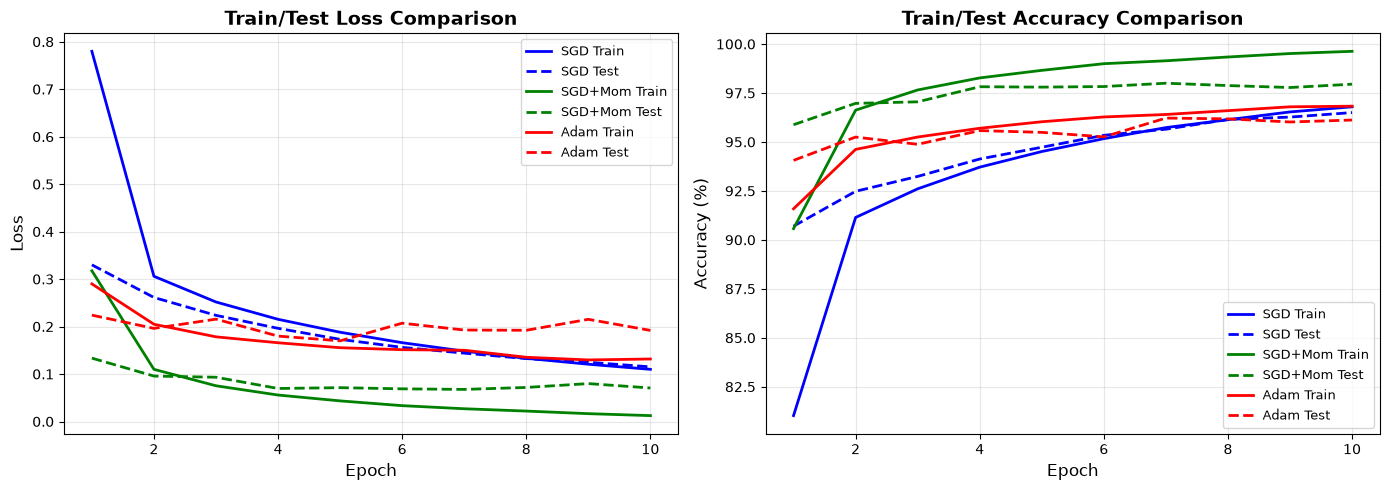

Optimizer            Train Loss   Test Loss    Train Acc    Test Acc    
--------------------------------------------------------------------------------
SGD                  0.1099       0.1151       96.80        96.50       
SGD + Momentum       0.0124       0.0706       99.63        97.95       
Adam                 0.1317       0.1919       96.83        96.12       


In [11]:
# Рисуем loss и accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history_sgd['train_loss']) + 1)

axes[0].plot(epochs, history_sgd['train_loss'], 'b-', label='SGD Train', linewidth=2)
axes[0].plot(epochs, history_sgd['test_loss'], 'b--', label='SGD Test', linewidth=2)

axes[0].plot(epochs, history_sgd_momentum['train_loss'], 'g-', label='SGD+Mom Train', linewidth=2)
axes[0].plot(epochs, history_sgd_momentum['test_loss'], 'g--', label='SGD+Mom Test', linewidth=2)

axes[0].plot(epochs, history_adam['train_loss'], 'r-', label='Adam Train', linewidth=2)
axes[0].plot(epochs, history_adam['test_loss'], 'r--', label='Adam Test', linewidth=2)

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Train/Test Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history_sgd['train_acc'], 'b-', label='SGD Train', linewidth=2)
axes[1].plot(epochs, history_sgd['test_acc'], 'b--', label='SGD Test', linewidth=2)

axes[1].plot(epochs, history_sgd_momentum['train_acc'], 'g-', label='SGD+Mom Train', linewidth=2)
axes[1].plot(epochs, history_sgd_momentum['test_acc'], 'g--', label='SGD+Mom Test', linewidth=2)

axes[1].plot(epochs, history_adam['train_acc'], 'r-', label='Adam Train', linewidth=2)
axes[1].plot(epochs, history_adam['test_acc'], 'r--', label='Adam Test', linewidth=2)

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Train/Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'Optimizer':<20} {'Train Loss':<12} {'Test Loss':<12} {'Train Acc':<12} {'Test Acc':<12}")
print("-"*80)
print(f"{'SGD':<20} {history_sgd['train_loss'][-1]:<12.4f} {history_sgd['test_loss'][-1]:<12.4f} {history_sgd['train_acc'][-1]:<12.2f} {history_sgd['test_acc'][-1]:<12.2f}")
print(f"{'SGD + Momentum':<20} {history_sgd_momentum['train_loss'][-1]:<12.4f} {history_sgd_momentum['test_loss'][-1]:<12.4f} {history_sgd_momentum['train_acc'][-1]:<12.2f} {history_sgd_momentum['test_acc'][-1]:<12.2f}")
print(f"{'Adam':<20} {history_adam['train_loss'][-1]:<12.4f} {history_adam['test_loss'][-1]:<12.4f} {history_adam['train_acc'][-1]:<12.2f} {history_adam['test_acc'][-1]:<12.2f}")


**Вопрос для отчёта:** какой оптимизатор сходится быстрее? У какого варианта наибольший train/test gap? Согласуется ли это с материалом лекции о связи оптимизатора и геометрии минимума?

_Ваш ответ:_

Быстрее всего в данном эксперименте сходится SGD + Momentum (наименьший loss).

Наибольший train/test gap также у SGD + Momentum:  \(99.63\%-97.95\%=1.68\%\).

Momentum помогает быстрее двигаться к минимуму и эффективнее проходить области с неудобной геометрией. При этом в данном случае он сильнее подгоняется под обучающую выборку, поэтому разрыв между train и test получается больше.


## 5. Серия B. Сравнение методов регуляризации

**Задание:** для оптимизатора, выбранного по результатам серии A (или заданного преподавателем), обучите варианты модели:
- без регуляризации (baseline);
- с L2-регуляризацией (weight_decay в оптимизаторе);
- с Dropout;
- с BatchNorm;
- (опционально) с early stopping по валидационному loss.


In [14]:
# Создаем модель без регуляризации
model_baseline = SimpleMLP(
    input_dim=784, 
    hidden_dim=128, 
    num_classes=10,
    use_dropout=False,
    use_batchnorm=False
).to(device)

optimizer_baseline = optim.SGD(model_baseline.parameters(), lr=0.005, momentum=0.9)
criterion = nn.CrossEntropyLoss()

# Обучаем
history_baseline = train_model(
    model_baseline, train_loader, test_loader, 
    optimizer_baseline, criterion, device, epochs=10
)

Epoch 1/10 | Train Loss: 0.4067, Train Acc: 88.34% | Test Loss: 0.1963, Test Acc: 94.16%
Epoch 2/10 | Train Loss: 0.1560, Train Acc: 95.41% | Test Loss: 0.1328, Test Acc: 95.97%
Epoch 3/10 | Train Loss: 0.1087, Train Acc: 96.71% | Test Loss: 0.1023, Test Acc: 96.74%
Epoch 4/10 | Train Loss: 0.0825, Train Acc: 97.52% | Test Loss: 0.0856, Test Acc: 97.34%
Epoch 5/10 | Train Loss: 0.0665, Train Acc: 98.00% | Test Loss: 0.0817, Test Acc: 97.53%
Epoch 6/10 | Train Loss: 0.0552, Train Acc: 98.27% | Test Loss: 0.0753, Test Acc: 97.71%
Epoch 7/10 | Train Loss: 0.0450, Train Acc: 98.64% | Test Loss: 0.0767, Test Acc: 97.57%
Epoch 8/10 | Train Loss: 0.0372, Train Acc: 98.89% | Test Loss: 0.0726, Test Acc: 97.68%
Epoch 9/10 | Train Loss: 0.0314, Train Acc: 99.06% | Test Loss: 0.0699, Test Acc: 97.79%
Epoch 10/10 | Train Loss: 0.0258, Train Acc: 99.26% | Test Loss: 0.0711, Test Acc: 97.78%


In [ ]:
# Создаем такую же модель
model_l2 = SimpleMLP(
    input_dim=784, 
    hidden_dim=128, 
    num_classes=10,
    use_dropout=False,
    use_batchnorm=False
).to(device)

# Добавляем регуляризацию
optimizer_l2 = optim.SGD(
    model_l2.parameters(), 
    lr=0.005,
    momentum=0.9,
    weight_decay=1e-4  # коэффициент L2-регуляризации (не дает весам сильно расти)
)

history_l2 = train_model(
    model_l2, train_loader, test_loader, 
    optimizer_l2, criterion, device, epochs=10
)

Epoch 1/10 | Train Loss: 0.4148, Train Acc: 87.83% | Test Loss: 0.1983, Test Acc: 93.91%
Epoch 2/10 | Train Loss: 0.1595, Train Acc: 95.30% | Test Loss: 0.1244, Test Acc: 96.13%
Epoch 3/10 | Train Loss: 0.1097, Train Acc: 96.72% | Test Loss: 0.1103, Test Acc: 96.59%
Epoch 4/10 | Train Loss: 0.0835, Train Acc: 97.50% | Test Loss: 0.0886, Test Acc: 97.06%
Epoch 5/10 | Train Loss: 0.0667, Train Acc: 98.00% | Test Loss: 0.0832, Test Acc: 97.36%
Epoch 6/10 | Train Loss: 0.0546, Train Acc: 98.36% | Test Loss: 0.0850, Test Acc: 97.41%
Epoch 7/10 | Train Loss: 0.0447, Train Acc: 98.65% | Test Loss: 0.0739, Test Acc: 97.70%
Epoch 8/10 | Train Loss: 0.0385, Train Acc: 98.83% | Test Loss: 0.0754, Test Acc: 97.73%
Epoch 9/10 | Train Loss: 0.0318, Train Acc: 99.06% | Test Loss: 0.0726, Test Acc: 97.76%
Epoch 10/10 | Train Loss: 0.0268, Train Acc: 99.25% | Test Loss: 0.0747, Test Acc: 97.74%


In [21]:
# Dropout
model_dropout = SimpleMLP(
    input_dim=784, 
    hidden_dim=128, 
    num_classes=10,
    use_dropout=True,        # Включаем dropout
    use_batchnorm=False,
    dropout_p=0.3            # Вероятность отключения нейрона
).to(device)

optimizer_dropout = optim.SGD(model_dropout.parameters(), lr=0.005, momentum=0.9)

history_dropout = train_model(
    model_dropout, train_loader, test_loader, 
    optimizer_dropout, criterion, device, epochs=10
)

Epoch 1/10 | Train Loss: 0.5279, Train Acc: 83.85% | Test Loss: 0.1939, Test Acc: 94.05%
Epoch 2/10 | Train Loss: 0.2318, Train Acc: 93.12% | Test Loss: 0.1312, Test Acc: 95.97%
Epoch 3/10 | Train Loss: 0.1810, Train Acc: 94.63% | Test Loss: 0.1178, Test Acc: 96.37%
Epoch 4/10 | Train Loss: 0.1524, Train Acc: 95.49% | Test Loss: 0.0973, Test Acc: 96.95%
Epoch 5/10 | Train Loss: 0.1350, Train Acc: 95.96% | Test Loss: 0.0922, Test Acc: 97.05%
Epoch 6/10 | Train Loss: 0.1207, Train Acc: 96.34% | Test Loss: 0.0866, Test Acc: 97.21%
Epoch 7/10 | Train Loss: 0.1087, Train Acc: 96.67% | Test Loss: 0.0806, Test Acc: 97.50%
Epoch 8/10 | Train Loss: 0.1016, Train Acc: 96.76% | Test Loss: 0.0753, Test Acc: 97.70%
Epoch 9/10 | Train Loss: 0.0959, Train Acc: 97.07% | Test Loss: 0.0761, Test Acc: 97.64%
Epoch 10/10 | Train Loss: 0.0910, Train Acc: 97.17% | Test Loss: 0.0727, Test Acc: 97.86%


In [19]:
# BatchNorm
model_batchnorm = SimpleMLP(
    input_dim=784, 
    hidden_dim=128, 
    num_classes=10,
    use_dropout=False,
    use_batchnorm=True       # Включаем batch normalization
).to(device)

optimizer_batchnorm = optim.SGD(model_batchnorm.parameters(), lr=0.005, momentum=0.9)

history_batchnorm = train_model(
    model_batchnorm, train_loader, test_loader, 
    optimizer_batchnorm, criterion, device, epochs=10
)

Epoch 1/10 | Train Loss: 0.2728, Train Acc: 92.43% | Test Loss: 0.1110, Test Acc: 96.70%
Epoch 2/10 | Train Loss: 0.1086, Train Acc: 96.85% | Test Loss: 0.0866, Test Acc: 97.40%
Epoch 3/10 | Train Loss: 0.0787, Train Acc: 97.58% | Test Loss: 0.0739, Test Acc: 97.70%
Epoch 4/10 | Train Loss: 0.0618, Train Acc: 98.14% | Test Loss: 0.0732, Test Acc: 97.76%
Epoch 5/10 | Train Loss: 0.0478, Train Acc: 98.59% | Test Loss: 0.0635, Test Acc: 98.19%
Epoch 6/10 | Train Loss: 0.0418, Train Acc: 98.75% | Test Loss: 0.0659, Test Acc: 98.02%
Epoch 7/10 | Train Loss: 0.0349, Train Acc: 98.99% | Test Loss: 0.0612, Test Acc: 98.09%
Epoch 8/10 | Train Loss: 0.0298, Train Acc: 99.08% | Test Loss: 0.0623, Test Acc: 97.96%
Epoch 9/10 | Train Loss: 0.0268, Train Acc: 99.23% | Test Loss: 0.0603, Test Acc: 98.16%
Epoch 10/10 | Train Loss: 0.0236, Train Acc: 99.30% | Test Loss: 0.0622, Test Acc: 97.99%


In [22]:
import pandas as pd

results_table = pd.DataFrame(columns=["variant", "train_acc", "test_acc", "gap"])

variants = [
    ("Baseline", history_baseline),
    ("L2 Regularization", history_l2),
    ("Dropout", history_dropout),
    ("BatchNorm", history_batchnorm),
]

for variant_name, history in variants:
    train_acc = history['train_acc'][-1]  # Последняя эпоха
    test_acc = history['test_acc'][-1]
    gap = train_acc - test_acc
    
    results_table = pd.concat([
        results_table, 
        pd.DataFrame([{
            "variant": variant_name,
            "train_acc": round(train_acc, 2),
            "test_acc": round(test_acc, 2),
            "gap": round(gap, 2)
        }])
    ], ignore_index=True)

# Сортируем по test_acc (от лучшего к худшему)
results_table = results_table.sort_values("test_acc", ascending=False).reset_index(drop=True)

# Отображаем таблицу
results_table

,variant,train_acc,test_acc,gap
0,BatchNorm,99.3,97.99,1.31
1,Dropout,97.17,97.86,-0.69
2,Baseline,99.26,97.78,1.48
3,L2 Regularization,99.25,97.74,1.52


**Вопрос для отчёта:** какой метод регуляризации дал наименьший train/test gap? Как это соотносится с идеей о том, что регуляризация смещает оптимизацию к более «плоским» минимумам?

_Ваш ответ:_ Наименьший gap дал Dropout, поскольку он снижает переобучение

## 6. Серия C. Проверка устойчивости к возмущениям входа

**Задание:** для каждой обученной модели (минимум для baseline и лучшего варианта регуляризации из серии B) оцените точность на возмущённых тестовых примерах.

Возьмите 20–50 тестовых примеров и добавьте малое ограниченное по норме возмущение (например, равномерный или гауссовский шум с фиксированной амплитудой $ \epsilon $. Сравните accuracy на чистых и возмущённых данных.


In [39]:
torch.manual_seed(RANDOM_STATE)

def add_noise(x, epsilon=1.0):
    noise = torch.randn_like(x)

    # Ограничиваем L_inf-норму шума
    noise = torch.clamp(noise, -epsilon, epsilon)

    return x + noise


In [40]:
def evaluate_perturbed(model, loader, device, epsilon=1.0, n_samples=50):
    model.eval()

    correct_clean = 0
    correct_perturbed = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            if data.dim() > 2:
                data = data.view(data.size(0), -1)

            # Берём только нужное количество
            remaining = n_samples - total
            data = data[:remaining]
            target = target[:remaining]

            # Чистые
            output_clean = model(data)
            pred_clean = output_clean.argmax(dim=1)
            correct_clean += (pred_clean == target).sum().item()

            # Возмущённые
            noisy_data = add_noise(data, epsilon)

            output_noisy = model(noisy_data)
            pred_noisy = output_noisy.argmax(dim=1)
            correct_perturbed += (pred_noisy == target).sum().item()

            total += target.size(0)

            if total >= n_samples:
                break

    clean_accuracy = 100 * correct_clean / total
    perturbed_accuracy = 100 * correct_perturbed / total
    drop = clean_accuracy - perturbed_accuracy

    return clean_accuracy, perturbed_accuracy, drop

In [41]:
results_perturbation = []

for name, model in [
    ("Baseline", model_baseline),
    ("BatchNorm", model_batchnorm),
    ("Dropout", model_dropout)
]:
    clean_acc, perturbed_acc, drop = evaluate_perturbed(
        model,
        test_loader,
        device,
        epsilon=1.0,
        n_samples=50
    )

    results_perturbation.append({
        "variant": name,
        "clean_accuracy": clean_acc,
        "perturbed_accuracy": perturbed_acc,
        "drop": drop
    })

results_perturbation = pd.DataFrame(results_perturbation)
results_perturbation

,variant,clean_accuracy,perturbed_accuracy,drop
0,Baseline,100.0,96.0,4.0
1,BatchNorm,100.0,100.0,0.0
2,Dropout,100.0,98.0,2.0


**Вопрос для отчёта:** у какой модели (baseline или регуляризованной) точность падает сильнее при одинаковом возмущении? Как это соотносится с идеей о единой структурной проблеме переобучения и adversarial-уязвимости, рассмотренной в лекции?

_Ваш ответ:_ Устойчивость к входным возмущениям может быть связана общей проблемой слабой обобщающей способности модели. Регуляризация, в частности BatchNorm и Dropout, может повысить устойчивость модели к небольшим возмущениям.

## 7. Итоговый вывод

**Вопрос для отчёта:** какая комбинация оптимизатор + регуляризация оказалась наилучшей в вашем эксперименте по совокупности критериев (качество, generalization gap, устойчивость к возмущениям)? Обоснуйте ответ ссылками на полученные графики и таблицы.

_Ваш ответ:_ Лучшей по совокупности критериев оказалась BatchNorm + SGD+Momentum: test accuracy 97.99%

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Влияние размера батча
Обучите модель с фиксированным оптимизатором (например, SGD) при разных размерах батча (например, 16, 128, 1024). Сравните итоговый train/test gap и устойчивость к возмущениям. Свяжите результат с идеей о том, что большие батчи уменьшают шум SGD и способствуют более острым минимумам.

### С2. Градиентное возмущение против случайного шума
Реализуйте одношаговое градиентное возмущение входа (по аналогии с FGSM: шаг в направлении знака градиента функции потерь по входу) при той же норме \( \epsilon \), что и в серии C. Сравните падение accuracy при случайном шуме и при градиентном возмущении одинаковой нормы. Объясните, почему градиентное возмущение обычно эффективнее.

### С3. Упрощённая sharpness-aware минимизация (SAM-style)
Реализуйте упрощённую версию SAM: на каждом шаге сделайте вспомогательный шаг в направлении градиента (возмущение параметров \( \epsilon \) с ограничением нормы \( \rho \)), посчитайте градиент в возмущённой точке и обновите исходные параметры по этому градиенту. Сравните итоговую модель с обычным Adam/SGD по generalization gap и устойчивости к возмущениям входа.

### С4. Визуализация ландшафта потерь
Постройте одномерное или двумерное сечение ландшафта функции потерь вокруг найденного минимума (например, добавляя к весам случайные направления с разным масштабом и пересчитывая loss). Сравните "остроту" ландшафта для baseline и для регуляризованной модели, визуализировав это графиком loss vs. amplitude.


## Влияние размера батча (C1)

In [42]:
from torch.utils.data import DataLoader

batch_sizes = [16, 128, 1024]
batch_results = []

for batch_size in batch_sizes:
    print(f"\n===== Batch size: {batch_size} =====")
    
    train_loader_bs = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    
    # Одинаковая архитектура для честного сравнения
    model = create_model().to(device)
    
    # Фиксированный оптимизатор
    optimizer = optim.SGD(
        model.parameters(),
        lr=0.01
    )
    
    history = train_model(
        model,
        train_loader_bs,
        test_loader,
        optimizer,
        criterion,
        device,
        epochs=10
    )
    
    train_acc = history["train_acc"][-1]
    test_acc = history["test_acc"][-1]
    gap = train_acc - test_acc
    
    batch_results.append({
        "batch_size": batch_size,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "gap": gap
    })


===== Batch size: 16 =====
Epoch 1/10 | Train Loss: 0.4145, Train Acc: 88.30% | Test Loss: 0.2085, Test Acc: 93.71%
Epoch 2/10 | Train Loss: 0.1750, Train Acc: 94.93% | Test Loss: 0.1349, Test Acc: 96.04%
Epoch 3/10 | Train Loss: 0.1206, Train Acc: 96.44% | Test Loss: 0.1081, Test Acc: 96.86%
Epoch 4/10 | Train Loss: 0.0911, Train Acc: 97.34% | Test Loss: 0.0916, Test Acc: 97.14%
Epoch 5/10 | Train Loss: 0.0726, Train Acc: 97.83% | Test Loss: 0.0856, Test Acc: 97.37%
Epoch 6/10 | Train Loss: 0.0593, Train Acc: 98.26% | Test Loss: 0.0775, Test Acc: 97.47%
Epoch 7/10 | Train Loss: 0.0501, Train Acc: 98.48% | Test Loss: 0.0776, Test Acc: 97.59%
Epoch 8/10 | Train Loss: 0.0421, Train Acc: 98.74% | Test Loss: 0.0756, Test Acc: 97.65%
Epoch 9/10 | Train Loss: 0.0358, Train Acc: 98.95% | Test Loss: 0.0749, Test Acc: 97.65%
Epoch 10/10 | Train Loss: 0.0300, Train Acc: 99.15% | Test Loss: 0.0735, Test Acc: 97.72%

===== Batch size: 128 =====
Epoch 1/10 | Train Loss: 1.2175, Train Acc: 67.71% |

In [43]:
batch_results = pd.DataFrame(batch_results)
batch_results

,batch_size,train_acc,test_acc,gap
0,16,99.151667,97.72,1.431667
1,128,95.006667,94.95,0.056667
2,1024,88.235000,89.14,-0.905000


При увеличении batch size снижается точность train и test, посколько количество обновлений параметров уменьшается. Модели не хватило 10 эпох для обучения

In [44]:
perturbation_batch_results = []

for batch_size in batch_sizes:
    train_loader_bs = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    
    model = create_model().to(device)
    
    optimizer = optim.SGD(
        model.parameters(),
        lr=0.01
    )
    
    train_model(
        model,
        train_loader_bs,
        test_loader,
        optimizer,
        criterion,
        device,
        epochs=10
    )
    
    clean_acc, perturbed_acc, drop = evaluate_perturbed(
        model,
        test_loader,
        device,
        epsilon=1.0,
        n_samples=50
    )
    
    perturbation_batch_results.append({
        "batch_size": batch_size,
        "clean_accuracy": clean_acc,
        "perturbed_accuracy": perturbed_acc,
        "drop": drop
    })

perturbation_batch_results = pd.DataFrame(perturbation_batch_results)
perturbation_batch_results

Epoch 1/10 | Train Loss: 0.4020, Train Acc: 88.86% | Test Loss: 0.2060, Test Acc: 93.73%
Epoch 2/10 | Train Loss: 0.1749, Train Acc: 94.82% | Test Loss: 0.1448, Test Acc: 95.52%
Epoch 3/10 | Train Loss: 0.1228, Train Acc: 96.38% | Test Loss: 0.1196, Test Acc: 96.49%
Epoch 4/10 | Train Loss: 0.0949, Train Acc: 97.22% | Test Loss: 0.0983, Test Acc: 96.92%
Epoch 5/10 | Train Loss: 0.0766, Train Acc: 97.77% | Test Loss: 0.0985, Test Acc: 96.76%
Epoch 6/10 | Train Loss: 0.0635, Train Acc: 98.10% | Test Loss: 0.0858, Test Acc: 97.30%
Epoch 7/10 | Train Loss: 0.0534, Train Acc: 98.42% | Test Loss: 0.0769, Test Acc: 97.61%
Epoch 8/10 | Train Loss: 0.0458, Train Acc: 98.66% | Test Loss: 0.0763, Test Acc: 97.71%
Epoch 9/10 | Train Loss: 0.0394, Train Acc: 98.84% | Test Loss: 0.0746, Test Acc: 97.73%
Epoch 10/10 | Train Loss: 0.0327, Train Acc: 99.08% | Test Loss: 0.0769, Test Acc: 97.73%
Epoch 1/10 | Train Loss: 1.1136, Train Acc: 74.80% | Test Loss: 0.4602, Test Acc: 87.93%
Epoch 2/10 | Train L

,batch_size,clean_accuracy,perturbed_accuracy,drop
0,16,98.0,98.0,0.0
1,128,96.0,94.0,2.0
2,1024,92.0,90.0,2.0


С увеличением batch size увеличивается влияние случайного шума. Это может быть связано с недообучением моделей на больших размерах батча. Также при небольшом batch size модель чаще лучше обобщает.

## Градиентное возмущение (C2)

In [45]:
def add_gradient_noise(model, x, target, criterion, epsilon=1.0):
    x = x.clone().detach().requires_grad_(True)
    
    output = model(x)
    loss = criterion(output, target)
    
    model.zero_grad()
    loss.backward()
    
    # Направление наибольшего увеличения ошибки
    gradient = x.grad.sign()
    
    x_adv = x + epsilon * gradient
    
    return x_adv.detach()

In [46]:
def compare_perturbations(model, loader, device, epsilon=1.0, n_samples=50):
    model.eval()
    
    correct_clean = 0
    correct_random = 0
    correct_gradient = 0
    total = 0
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        if data.dim() > 2:
            data = data.view(data.size(0), -1)
        
        remaining = n_samples - total
        data = data[:remaining]
        target = target[:remaining]
        
        # Чистые данные
        with torch.no_grad():
            output = model(data)
            pred = output.argmax(dim=1)
            correct_clean += (pred == target).sum().item()
        
        # Случайный шум
        noisy_data = add_noise(data, epsilon)
        
        with torch.no_grad():
            output = model(noisy_data)
            pred = output.argmax(dim=1)
            correct_random += (pred == target).sum().item()
        
        # Градиентное возмущение
        adv_data = add_gradient_noise(
            model,
            data,
            target,
            criterion,
            epsilon
        )
        
        with torch.no_grad():
            output = model(adv_data)
            pred = output.argmax(dim=1)
            correct_gradient += (pred == target).sum().item()
        
        total += target.size(0)
        
        if total >= n_samples:
            break
    
    clean_acc = 100 * correct_clean / total
    random_acc = 100 * correct_random / total
    gradient_acc = 100 * correct_gradient / total
    
    return clean_acc, random_acc, gradient_acc

In [ ]:
c2_results = []

for name, model in [
    ("Baseline", model_baseline),
    ("Dropout", model_dropout)
]:
    
    clean_acc, random_acc, gradient_acc = compare_perturbations(
        model,
        test_loader,
        device,
        epsilon=0.1, # Шум в 10 раз меньше
        n_samples=50
    )
    
    c2_results.append({
        "variant": name,
        "clean_accuracy": clean_acc,
        "random_noise": random_acc,
        "gradient_noise": gradient_acc,
        "random_drop": clean_acc - random_acc,
        "gradient_drop": clean_acc - gradient_acc
    })

c2_results = pd.DataFrame(c2_results)
c2_results

,variant,clean_accuracy,random_noise,gradient_noise,random_drop,gradient_drop
0,Baseline,100.0,100.0,64.0,0.0,36.0
1,Dropout,100.0,100.0,92.0,0.0,8.0


Dropout показал сильную устойчивость против градиентного возмущения входа, поскольку модель меньше зависит от отдельных признаков.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны обе серии экспериментов (A и B) и минимум базовая проверка устойчивости (серия C).
